In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asheniranga/leaf-disease-dataset-combination")

print("Path to dataset files:", path)

100%|██████████| 761M/761M [00:09<00:00, 82.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asheniranga/leaf-disease-dataset-combination/versions/1


In [ ]:
import os
import shutil

# 1. Create a clean folder in Colab for our project
base_dir = '/content/leaf_binary_dataset'
os.makedirs(f'{base_dir}/healthy', exist_ok=True)
os.makedirs(f'{base_dir}/diseased', exist_ok=True)

# 2. Path from your previous cell output
data_path = path

print("Sorting images... please wait.")

# 3. Walk through the downloaded folders and copy images
for root, dirs, files in os.walk(data_path):
    for folder in dirs:
        src_folder = os.path.join(root, folder)

        # Binary logic: if 'healthy' is in the name, it goes to healthy
        if 'healthy' in folder.lower():
            target_folder = f'{base_dir}/healthy'
        else:
            target_folder = f'{base_dir}/diseased'

        # Copy the files
        for img in os.listdir(src_folder):
            if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(os.path.join(src_folder, img), os.path.join(target_folder, img))

print(f"Done! Healthy images: {len(os.listdir(base_dir + '/healthy'))}")
print(f"Done! Diseased images: {len(os.listdir(base_dir + '/diseased'))}")

Sorting images... please wait.
Done! Healthy images: 7598
Done! Diseased images: 30749


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Save class names BEFORE mapping
class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize pixel values (0-255 → 0-1)
rescale  = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y:   (rescale(x), y))

# Optional: prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Dataset ready!")
print(f"Class 0: {class_names[0]}")
print(f"Class 1: {class_names[1]}")

Found 38347 files belonging to 2 classes.
Using 30678 files for training.
Found 38347 files belonging to 2 classes.
Using 7669 files for validation.
Classes: ['diseased', 'healthy']
Dataset ready!
Class 0: diseased
Class 1: healthy


In [ ]:
# Base model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Unfreeze last 20 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Full model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
959/959 ━━━━━━━━━━━━━━━━━━━━ 104s 82ms/step - accuracy: 0.9110 - loss: 0.2337 - val_accuracy: 0.7537 - val_loss: 0.8438
Epoch 2/5
959/959 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9605 - loss: 0.0997 - val_accuracy: 0.9180 - val_loss: 0.2586
Epoch 3/5
959/959 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.9726 - loss: 0.0679 - val_accuracy: 0.9688 - val_loss: 0.0738
Epoch 4/5
959/959 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9786 - loss: 0.0527 - val_accuracy: 0.9695 - val_loss: 0.0728
Epoch 5/5
959/959 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step - accuracy: 0.9820 - loss: 0.0435 - val_accuracy: 0.9675 - val_loss: 0.0742


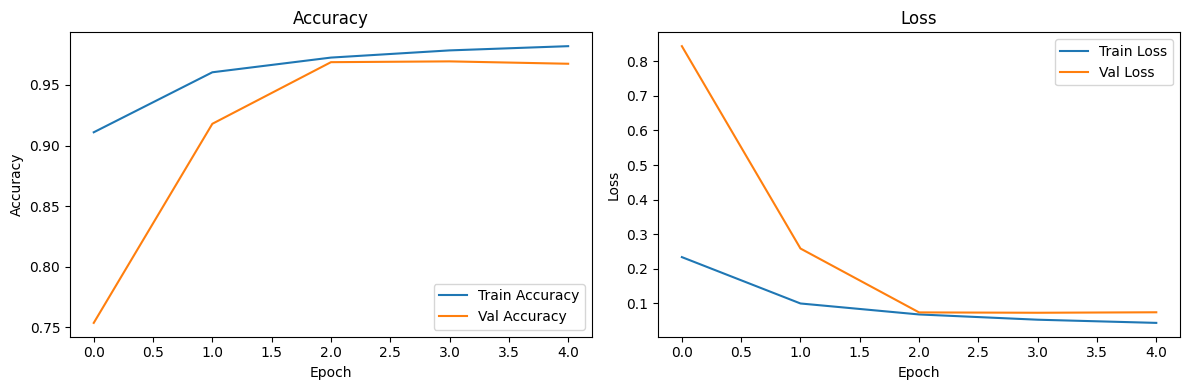

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ← Add this back
base_dir = '/content/leaf_binary_dataset'

# Feature extractor
feature_extractor = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    pooling='avg',
    weights='imagenet'
)

feature_extractor = tf.function(feature_extractor, reduce_retracing=True)

def extract_features_fast(folder, label, batch_size=256):
    features, labels = [], []
    img_paths = [
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    total = len(img_paths)

    for i in range(0, total, batch_size):
        batch_paths = img_paths[i:i + batch_size]
        batch_imgs  = []

        for img_path in batch_paths:
            img     = image.load_img(img_path, target_size=(224, 224))
            img_arr = image.img_to_array(img)
            batch_imgs.append(img_arr)

        batch_imgs  = np.array(batch_imgs, dtype=np.float32)
        batch_imgs  = preprocess_input(batch_imgs)
        batch_feats = feature_extractor(batch_imgs, training=False)
        batch_feats = batch_feats.numpy()

        features.extend(batch_feats)
        labels.extend([label] * len(batch_paths))

        done = min(i + batch_size, total)
        pct  = (done / total) * 100
        print(f"  Progress: {done}/{total}  ({pct:.1f}%)", end='\r')

    print()
    return features, labels

print("Extracting healthy features...")
healthy_feat,  healthy_labels  = extract_features_fast(f'{base_dir}/healthy',  1)

print("Extracting diseased features...")
diseased_feat, diseased_labels = extract_features_fast(f'{base_dir}/diseased', 0)

X = np.array(healthy_feat  + diseased_feat)
y = np.array(healthy_labels + diseased_labels)

print(f"\nTotal features extracted: {len(X)}")

Extracting healthy features...
  Progress: 7598/7598  (100.0%)
Extracting diseased features...
  Progress: 30749/30749  (100.0%)

Total features extracted: 38347


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# MinMaxScaler for Naive Bayes
mm_scaler  = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm  = mm_scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 30677
Testing  samples : 7670


In [ ]:
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(clf, X_test, y_test, model_name):
    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"  Accuracy : {acc * 100:.2f}%")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Diseased', 'Healthy']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Diseased', 'Healthy'],
                yticklabels=['Diseased', 'Healthy'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return acc * 100

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_dir = '/content/leaf_binary_dataset'

feature_extractor = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    pooling='avg',
    weights='imagenet'
)
feature_extractor = tf.function(feature_extractor, reduce_retracing=True)

def extract_features_fast(folder, label, batch_size=256):
    features, labels = [], []
    img_paths = [
        os.path.join(folder, f) for f in os.listdir(folder)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    total = len(img_paths)

    for i in range(0, total, batch_size):
        batch_paths = img_paths[i:i + batch_size]
        batch_imgs  = []

        for img_path in batch_paths:
            img     = image.load_img(img_path, target_size=(224, 224))
            img_arr = image.img_to_array(img)
            batch_imgs.append(img_arr)

        batch_imgs  = np.array(batch_imgs, dtype=np.float32)
        batch_imgs  = preprocess_input(batch_imgs)
        batch_feats = feature_extractor(batch_imgs, training=False)
        batch_feats = batch_feats.numpy()

        features.extend(batch_feats)
        labels.extend([label] * len(batch_paths))

        done = min(i + batch_size, total)
        print(f"  Progress: {done}/{total} ({(done/total)*100:.1f}%)", end='\r')

    print()
    return features, labels

print("Extracting healthy features...")
healthy_feat,  healthy_labels  = extract_features_fast(f'{base_dir}/healthy',  1)

print("Extracting diseased features...")
diseased_feat, diseased_labels = extract_features_fast(f'{base_dir}/diseased', 0)

X = np.array(healthy_feat  + diseased_feat)
y = np.array(healthy_labels + diseased_labels)

print(f"Done! X: {X.shape}, y: {y.shape}")

Extracting healthy features...
  Progress: 7598/7598 (100.0%)
Extracting diseased features...
  Progress: 30749/30749 (100.0%)
Done! X: (38347, 1280), y: (38347,)


Training Logistic Regression...

  Logistic Regression
  Accuracy : 95.18%
              precision    recall  f1-score   support

    Diseased       0.97      0.97      0.97      6150
     Healthy       0.87      0.89      0.88      1520

    accuracy                           0.95      7670
   macro avg       0.92      0.93      0.92      7670
weighted avg       0.95      0.95      0.95      7670



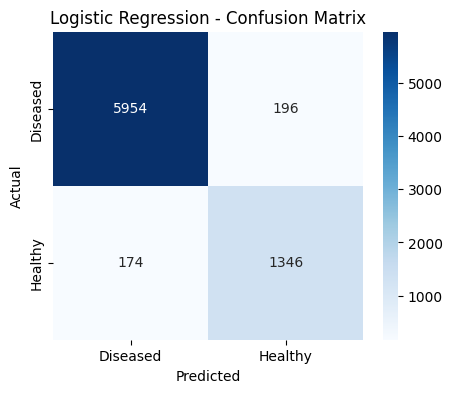

Training Naive Bayes...

  Naive Bayes
  Accuracy : 89.45%
              precision    recall  f1-score   support

    Diseased       0.94      0.92      0.93      6150
     Healthy       0.71      0.78      0.75      1520

    accuracy                           0.89      7670
   macro avg       0.83      0.85      0.84      7670
weighted avg       0.90      0.89      0.90      7670



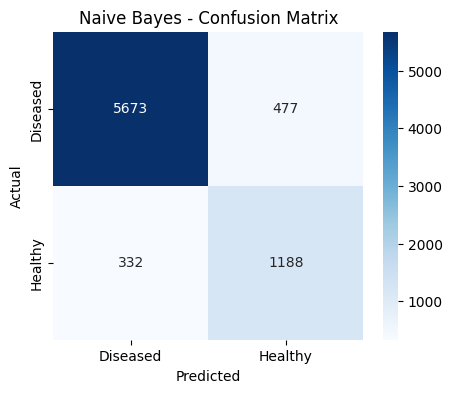

Training Decision Tree...

  Decision Tree
  Accuracy : 89.50%
              precision    recall  f1-score   support

    Diseased       0.93      0.94      0.93      6150
     Healthy       0.75      0.71      0.73      1520

    accuracy                           0.90      7670
   macro avg       0.84      0.83      0.83      7670
weighted avg       0.89      0.90      0.89      7670



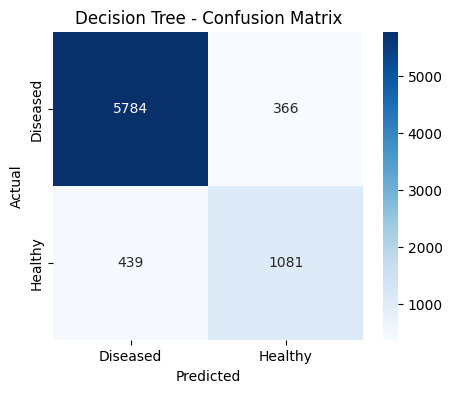

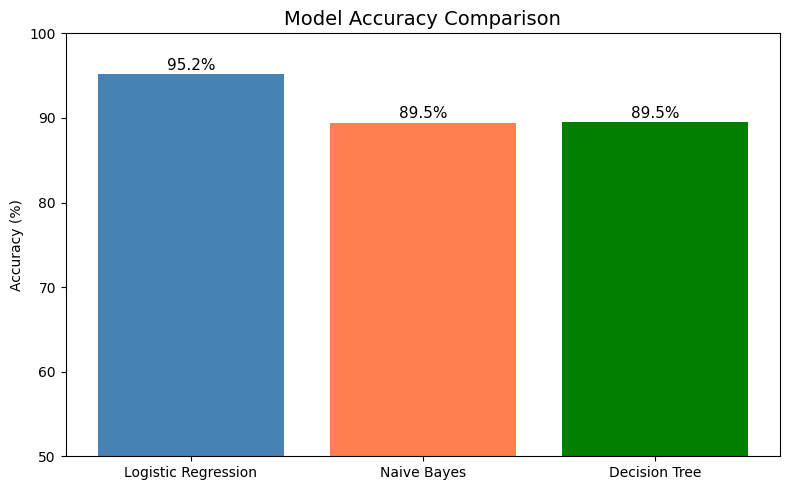

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

mm_scaler  = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm  = mm_scaler.transform(X_test)

def evaluate_model(clf, X_test, y_test, model_name):
    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"  Accuracy : {acc * 100:.2f}%")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Diseased', 'Healthy']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Diseased', 'Healthy'],
                yticklabels=['Diseased', 'Healthy'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return acc * 100

results = {}

# 1. Logistic Regression (~30 secs)
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=500, solver='saga', n_jobs=-1)
lr.fit(X_train_sc, y_train)
results['Logistic Regression'] = evaluate_model(
    lr, X_test_sc, y_test, "Logistic Regression")

# 2. Naive Bayes (~2 secs)
print("Training Naive Bayes...")
nb = GaussianNB()
nb.fit(X_train_mm, y_train)
results['Naive Bayes'] = evaluate_model(
    nb, X_test_mm, y_test, "Naive Bayes")

# 3. Decision Tree (~5 secs)
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_sc, y_train)
results['Decision Tree'] = evaluate_model(
    dt, X_test_sc, y_test, "Decision Tree")

# Compare chart
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'coral', 'green']
bars   = plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(50, 100)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. This part triggers the upload from your computer
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0] # Gets the name of the file you just picked
    print(f"File uploaded: {img_path}")

    # 2. Your prediction logic
    def predict_leaf(img_path):
        # Load and prepare image [cite: 243, 355]
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # Preprocess specifically for MobileNetV2 [cite: 221, 251, 363]
        img_preprocessed = preprocess_input(img_array)

        # Extract features using the feature_extractor you defined [cite: 231, 252, 364]
        features = feature_extractor(img_preprocessed, training=False)
        features_numpy = features.numpy()

        # Scale features using the scaler you fitted earlier [cite: 292, 398]
        features_scaled = scaler.transform(features_numpy)

        # Predict using Logistic Regression [cite: 430, 432]
        prediction = lr.predict(features_scaled)

        # Mapping: 0=Diseased, 1=Healthy [cite: 88, 89, 267, 273, 373, 375]
        result = "Healthy" if prediction[0] == 1 else "Diseased"
        return result

    # 3. Show the result
    final_result = predict_leaf(img_path)
    print("-" * 30)
    print(f"THE LEAF IS: {final_result}")
    print("-" * 30)

Saving images.jfif to images (2).jfif
File uploaded: images (2).jfif
------------------------------
THE LEAF IS: Diseased
------------------------------


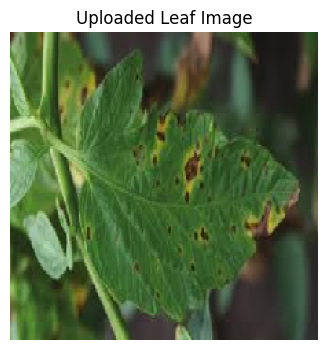

------------------------------
Prediction Result: Diseased
------------------------------


In [ ]:
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing import image

# Display uploaded image
img = image.load_img(img_path, target_size=(224, 224))

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("Uploaded Leaf Image")
plt.show()

# Prediction
final_result = predict_leaf(img_path)

print("-" * 30)
print(f"Prediction Result: {final_result}")
print("-" * 30)